# generate_and_save_noise_scenarios.py

In [ ]:
pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.8 MB/s eta 0:00:00


In [ ]:
import os
import zipfile
import re
import osmnx as ox
import numpy as np
import pandas as pd
import json
from noise_scenarios import (
    generate_noise_scenarios,
    visualize_modified_roads,
    check_warehouses_accessibility
)

In [ ]:
# 1. Подготовка данных
if not os.path.exists('raw_data'):
    if os.path.exists('raw_data.zip'):
        import zipfile
        with zipfile.ZipFile('raw_data.zip', 'r') as zf:
            zf.extractall('.')
        print("raw_data.zip распакован")
    else:
        raise FileNotFoundError("Не найден raw_data.zip")

In [ ]:
# 2. Загрузка графа и складов
graph = ox.load_graphml("raw_data/moscow_region_drive_network.graphml")

with open("raw_data/warehouses_rc_rfc_coordinates.json", "r", encoding="utf-8") as f:
    warehouses = json.load(f)
warehouses_df = pd.DataFrame(warehouses)

# Привязка складов к узлам
warehouse_nodes = []
for lat, lon in zip(warehouses_df['latitude'], warehouses_df['longitude']):
    node = ox.distance.nearest_nodes(graph, lon, lat)
    warehouse_nodes.append(node)
print(f"Загружено {len(warehouse_nodes)} складов")

Загружено 12 складов


In [ ]:
# 3. Назначение скоростей
DEFAULT_SPEEDS = {
    'motorway': 100, 'motorway_link': 80, 'trunk': 70, 'trunk_link': 65,
    'primary': 60, 'primary_link': 50, 'secondary': 50, 'secondary_link': 40,
    'tertiary': 40, 'tertiary_link': 30, 'residential': 30, 'living_street': 20,
    'unclassified': 30, 'service': 15, None: 30
}

for u, v, key, data in graph.edges(keys=True, data=True):
    hw = data.get('highway')
    if isinstance(hw, list):
        hw = hw[0] if hw else None
    raw_ms = data.get('maxspeed')
    if isinstance(raw_ms, list):
        raw_ms = raw_ms[0] if raw_ms else None
    parsed_speed = None
    if raw_ms:
        ms_str = str(raw_ms).strip().lower()
        if 'mph' in ms_str:
            ms_str = ms_str.replace('mph', '')
            match = re.search(r'(\d+)', ms_str)
            if match:
                parsed_speed = float(match.group(1)) * 1.60934
        else:
            match = re.search(r'(\d+)', ms_str)
            if match:
                parsed_speed = float(match.group(1))
    data['speed_kph'] = parsed_speed if (parsed_speed and parsed_speed > 0) else DEFAULT_SPEEDS.get(hw, 30)
print("Скорости назначены.")

Скорости назначены.


Найдено важных дорог: 15873
Дорог МКАД: 384, основных шоссе: 3590
Добавлены пробки на 2380 дорогах (множитель 8)


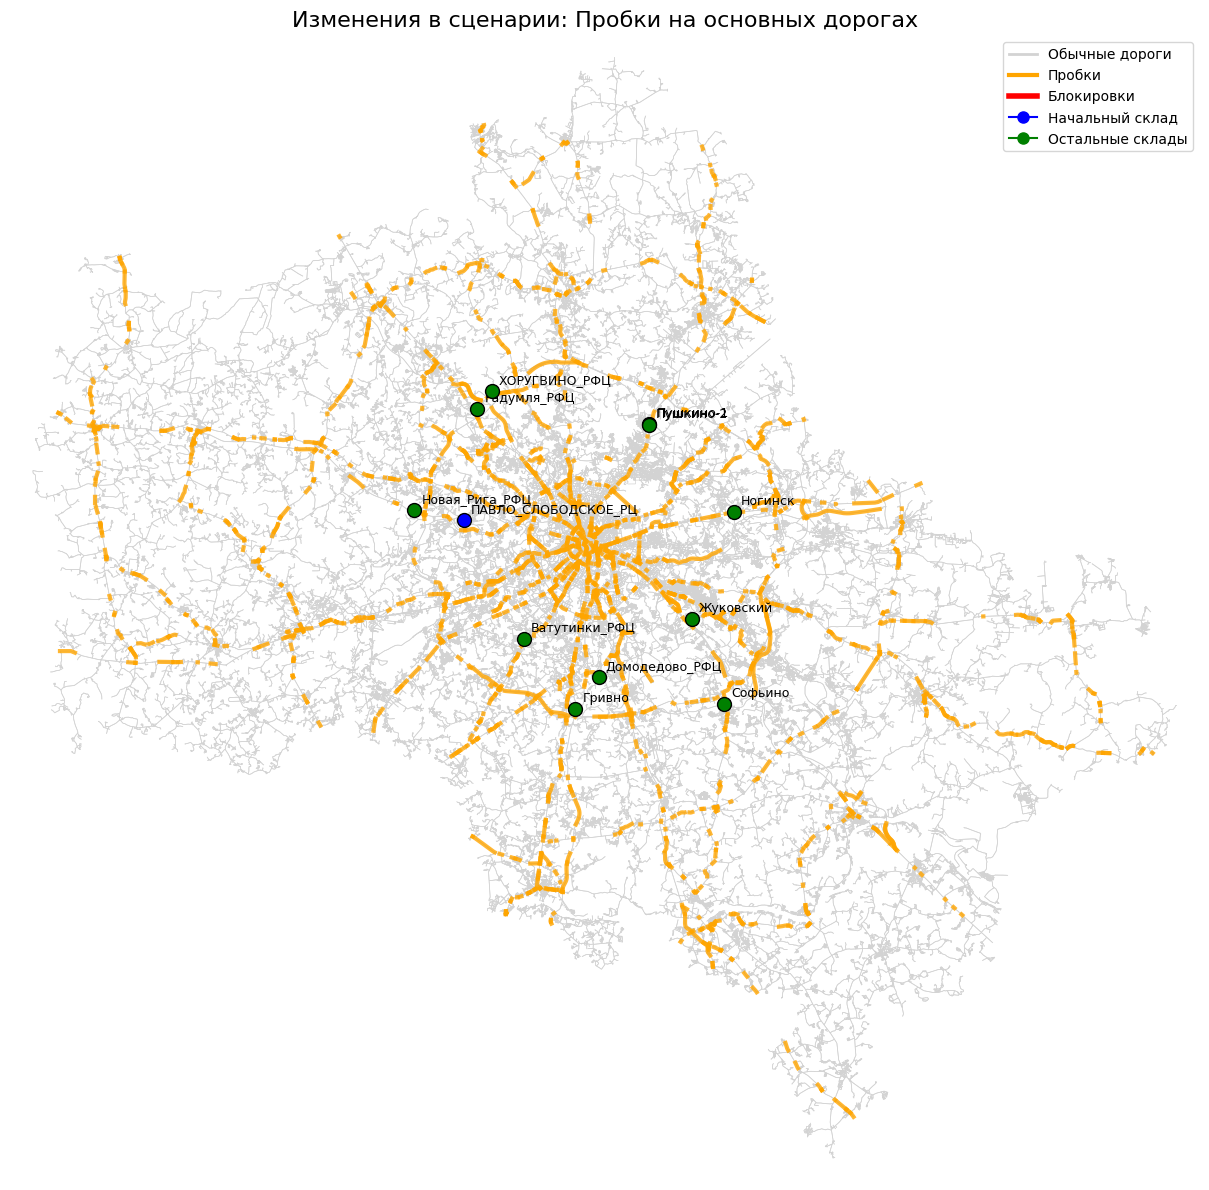

Карта изменений сохранена: noise_scenarios/modified_roads_Пробки_на_основных_дорогах.png
Заблокировано 173 дорог
Добавлены пробки на 1904 дорогах (множитель 8)


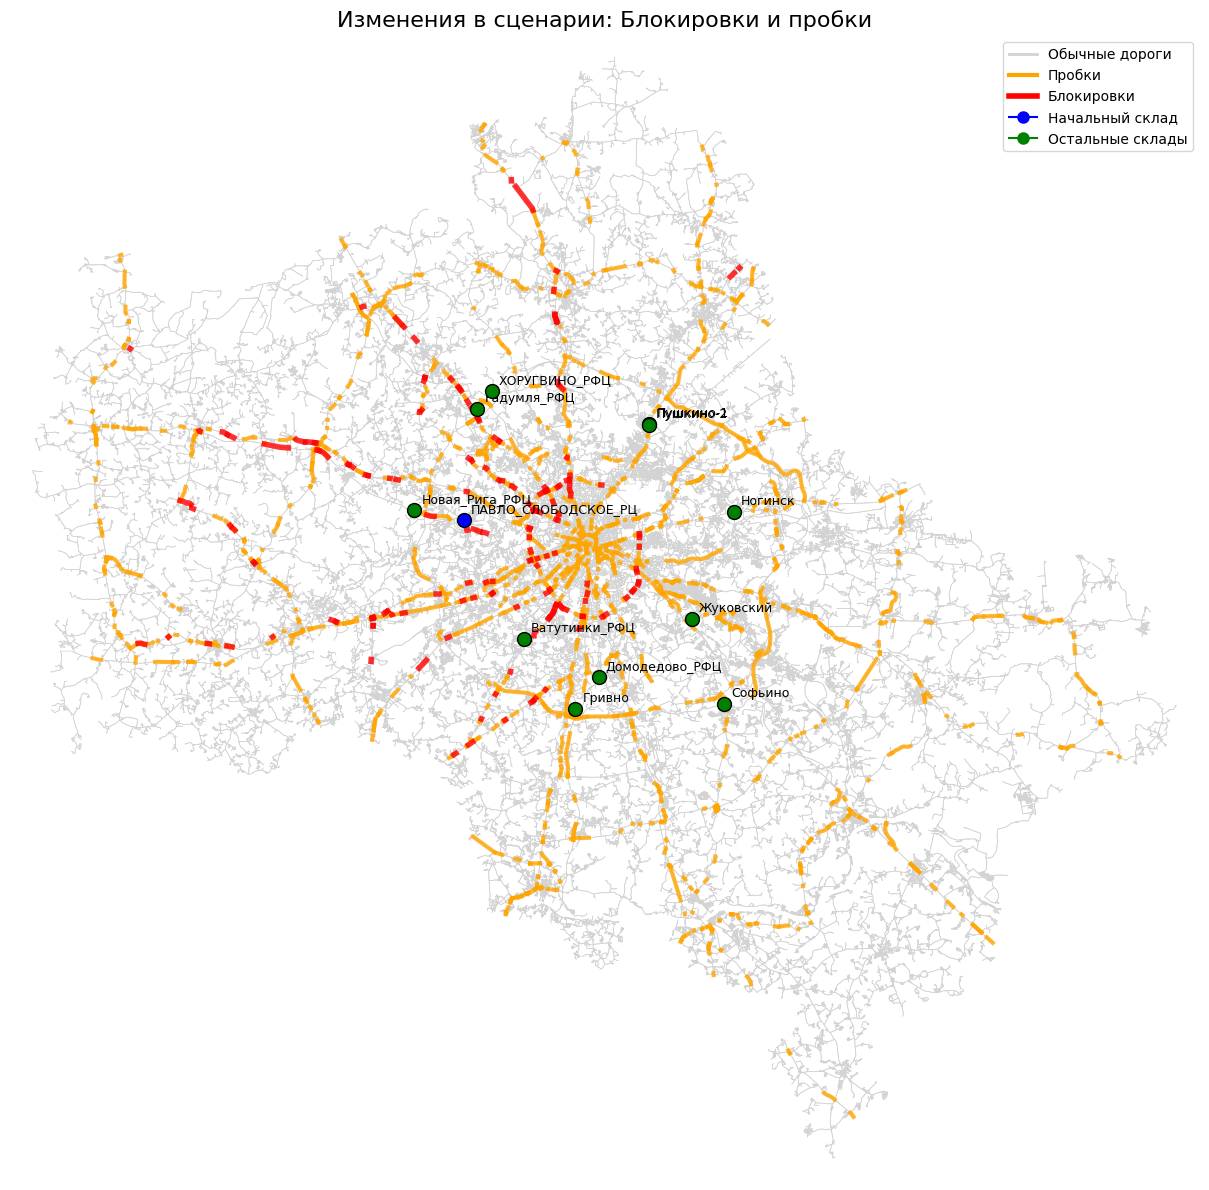

Карта изменений сохранена: noise_scenarios/modified_roads_Блокировки_и_пробки.png
Заблокировано 64 дорог
Добавлены пробки на 1269 дорогах (множитель 4)


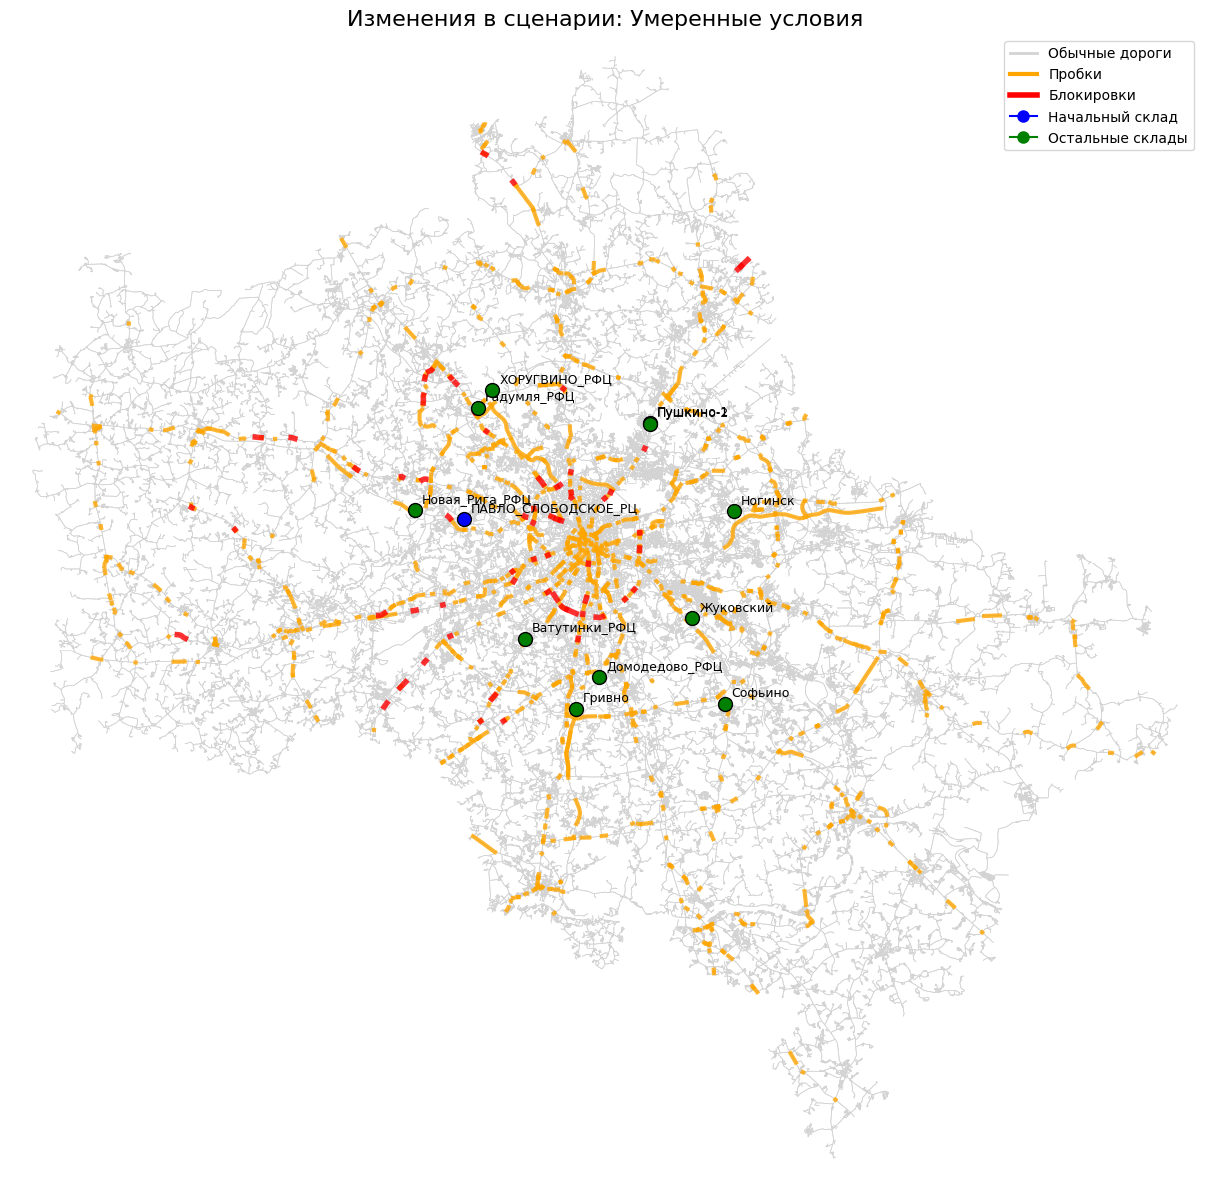

Карта изменений сохранена: noise_scenarios/modified_roads_Умеренные_условия.png


In [ ]:
# 3. Генерация сценариев шума
# Эта функция создаст 4 графа (Без_шума, Пробки, Блокировки+Пробки, Умеренные_условия)
# и автоматически сохранит визуализации в папку noise_scenarios/
scenario_graphs = generate_noise_scenarios(
    graph,
    warehouses_df,
    warehouse_nodes,
    start_index=0,
    random_seed=42,
    save_visualizations=True   # <-- включает отрисовку карт
)

In [ ]:
# 4. Проверка достижимости
print("\nПроверка достижимости складов:")
for name, g in scenario_graphs.items():
    ok = check_warehouses_accessibility(g, warehouse_nodes,
                                        warehouses_df['name'].tolist())
    print(f"  {name}: {'OK' if ok else 'Проблема'}")


Проверка достижимости складов:
Все склады достижимы.
  Без шума: OK
Все склады достижимы.
  Пробки: OK
Все склады достижимы.
  Блокировки+Пробки: OK
Все склады достижимы.
  Умеренные условия: OK


In [ ]:
# 4. Сохранение графов в отдельную папку
save_dir = "noise_graphs"
os.makedirs(save_dir, exist_ok=True)

for name, g in scenario_graphs.items():
    safe_name = name.replace('+', '_').replace(' ', '_')
    filepath = os.path.join(save_dir, f"graph_{safe_name}.graphml")
    ox.save_graphml(g, filepath)
    print(f"Граф '{name}' сохранён: {filepath}")

Граф 'Без шума' сохранён: noise_graphs/graph_Без_шума.graphml
Граф 'Пробки' сохранён: noise_graphs/graph_Пробки.graphml
Граф 'Блокировки+Пробки' сохранён: noise_graphs/graph_Блокировки_Пробки.graphml
Граф 'Умеренные условия' сохранён: noise_graphs/graph_Умеренные_условия.graphml


In [ ]:
# 5. Архивирование папки с графами
zip_graphs = "noise_graphs.zip"
with zipfile.ZipFile(zip_graphs, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(save_dir):
        for file in files:
            full = os.path.join(root, file)
            arcname = os.path.relpath(full, start=save_dir)
            zf.write(full, arcname)
print(f"Архив графов создан: {zip_graphs}")

Архив графов создан: noise_graphs.zip


In [ ]:
vis_dir = "noise_scenarios"
zip_vis = "noise_scenarios.zip"
with zipfile.ZipFile(zip_vis, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(vis_dir):
        for file in files:
            full = os.path.join(root, file)
            arcname = os.path.relpath(full, start=vis_dir)
            zf.write(full, arcname)
print(f"Архив с визуализациями создан: {zip_vis}")

Архив с визуализациями создан: noise_scenarios.zip


# distance

In [ ]:
# расстояние
import os
import zipfile
import osmnx as ox
import networkx as nx
import numpy as np
import json

In [ ]:
# Распаковка необходимых архивов
if not os.path.exists('noise_graphs'):
    with zipfile.ZipFile('noise_graphs.zip', 'r') as zf:
        zf.extractall('.')
    print("noise_graphs.zip распакован")

if not os.path.exists('raw_data'):
    with zipfile.ZipFile('raw_data.zip', 'r') as zf:
        zf.extractall('.')
    print("raw_data.zip распакован")

In [ ]:
# Загрузка складов
with open("raw_data/warehouses_rc_rfc_coordinates.json", "r") as f:
    warehouses = json.load(f)
warehouse_nodes = []
graph_baseline = ox.load_graphml("noise_graphs/graph_Без_шума.graphml")
for lat, lon in zip([w['latitude'] for w in warehouses], [w['longitude'] for w in warehouses]):
    node = ox.distance.nearest_nodes(graph_baseline, lon, lat)
    warehouse_nodes.append(node)
n = len(warehouse_nodes)

# Папка для матриц расстояний
os.makedirs("distance_matrices", exist_ok=True)

scenario_names = {
    "Без_шума": "graph_Без_шума.graphml",
    "Пробки": "graph_Пробки.graphml",
    "Блокировки+Пробки": "graph_Блокировки_Пробки.graphml",
    "Умеренные_условия": "graph_Умеренные_условия.graphml"
}

In [ ]:
for scenario, filename in scenario_names.items():
    print(f"Обрабатывается {scenario}")
    g = ox.load_graphml(os.path.join("noise_graphs", filename))

    # Обеспечиваем корректный атрибут travel_time (число) для каждого ребра
    for u, v, key, data in g.edges(keys=True, data=True):
        # GraphML может вернуть строки, поэтому явно приводим к float
        length_val = float(data['length'])
        speed_val = float(data.get('speed_kph', 30))
        # Вычисляем, если travel_time отсутствует или не является числом
        if 'travel_time' not in data or not isinstance(data['travel_time'], (int, float)):
            data['travel_time'] = length_val / (speed_val * 1000 / 3600)

    dist_mat = np.full((n, n), np.inf)
    for i in range(n):
        for j in range(n):
            if i == j:
                dist_mat[i][j] = 0.0
                continue
            try:
                path = nx.shortest_path(g, warehouse_nodes[i], warehouse_nodes[j],
                                        weight='travel_time')
                total_dist = 0.0
                for u, v in zip(path[:-1], path[1:]):
                    edge = g.edges[u, v, 0]
                    # original_length (если есть) – реальная длина без пробок, иначе берём length
                    # Оба атрибута могут быть строками при загрузке из GraphML → явный float
                    length_val = float(edge.get('original_length', edge['length']))
                    total_dist += length_val
                dist_mat[i][j] = total_dist
            except nx.NetworkXNoPath:
                pass

    np.save(f"distance_matrices/distance_matrix_{scenario}.npy", dist_mat)
    print(f"  Матрица расстояний сохранена: distance_matrix_{scenario}.npy")

Обрабатывается Без_шума
  Матрица расстояний сохранена: distance_matrix_Без_шума.npy
Обрабатывается Пробки
  Матрица расстояний сохранена: distance_matrix_Пробки.npy
Обрабатывается Блокировки+Пробки
  Матрица расстояний сохранена: distance_matrix_Блокировки+Пробки.npy
Обрабатывается Умеренные_условия
  Матрица расстояний сохранена: distance_matrix_Умеренные_условия.npy


In [ ]:
# Архивирование в отдельный zip
with zipfile.ZipFile("distance_matrices.zip", 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk("distance_matrices"):
        for file in files:
            full = os.path.join(root, file)
            arcname = os.path.relpath(full, start="distance_matrices")
            zf.write(full, arcname)
print("Архив distance_matrices.zip создан.")

Архив distance_matrices.zip создан.
